# mlmolprop quickstart: end-to-end QSAR pipeline

This notebook walks through the full workflow -- preparing molecules,
computing descriptors, building a dataset, preprocessing it, comparing
algorithms, searching hyperparameters and feature counts together, and
inspecting the winning model -- then goes further: global and per-molecule
interpretability, 2D structure depictions, a low-dimensional activity map,
clustering, and a classification pass with a small Keras deep-learning
model.

**About the data:** `examples/data/esol_subset.csv` is a 70-compound,
stratified sample of the **ESOL / Delaney aqueous solubility dataset**
(Delaney, J.S. *ESOL: Estimating Aqueous Solubility Directly from
Molecular Structure.* J. Chem. Inf. Comput. Sci. 2004, 44, 1000-1005),
via its public redistribution in
[MoleculeNet/DeepChem](https://github.com/deepchem/deepchem). The
`measured_logS` column is real experimental data (measured aqueous
solubility, log mol/L) -- not synthetic.

All outputs this notebook writes (prepared structures, descriptor tables,
diagnostic CSVs) go into `examples/output/`, which is git-ignored.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlmolprop import mol_enumerate, desc, dataframe, data_prep, Model

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
os.chdir(OUTPUT_DIR)
np.random.seed(0)

Failed to patch pandas - PandasTools will have limited functionality


## 1. Load the dataset

70 real compounds (pesticides, drugs, hormones, solvents, ...) with
measured aqueous solubility, spanning a wide range (very soluble to
very insoluble).

In [2]:
esol = pd.read_csv("../data/esol_subset.csv")
print(f"{len(esol)} compounds, measured_logS range: "
      f"[{esol['measured_logS'].min():.2f}, {esol['measured_logS'].max():.2f}]")
esol.head()

70 compounds, measured_logS range: [-8.33, 0.62]


,name,smiles,measured_logS
0,1_2_3_4_tetrachlorobenzene,Clc1ccc(Cl)c(Cl)c1Cl,-4.57
1,1_2_benzenediol,Oc1ccccc1O,0.62
2,1_4_dichlorobenzene,Clc1ccc(Cl)cc1,-3.27
3,1_nonyne,CCCCCCCC#C,-4.24
4,2_2_4_trimethylpentane,CC(C)CC(C)(C)C,-4.74


## 2. Prepare molecules

`mol_enumerate` strips salts, embeds a 3D conformer, and computes Gasteiger
charges for each molecule, writing both a 3D and a 2D SDF. Molecules that
fail preparation (e.g. RDKit's default salt list can strip some small
acids down to nothing) are skipped with a printed warning rather than
silently replaced by a placeholder -- none of this particular set happen
to trigger that, but it's worth knowing about for your own data.

In [3]:
esol[["smiles", "name"]].to_csv("molecules.smi", index=False)

prepared = mol_enumerate(
    "molecules.smi", "prepared_3d.sdf", "prepared_2d.sdf", input_format="smi"
)
print(f"prepared {len(prepared)} of {len(esol)} molecules")

len(input_molecules) 70
0 1_2_3_4_tetrachlorobenzene to 3d


50 n_methylaniline to 3d


prepared 70 of 70 molecules


## 3. Generate descriptors and merge in the real activity

`desc()` computes RDKit descriptors for every prepared molecule (the
"interpretable" subset: counts, fragment counts, molecular weight, TPSA --
easy to reason about). `dataframe()` merges those with the measured
solubility, matching by molecule name.

In [4]:
desc_result = desc("prepared_3d.sdf", source="sdf", selected_des="interpretable")
names, descriptor_names, values = desc_result
print(f"{len(descriptor_names)} descriptors computed for {len(names)} molecules")

esol[["name", "measured_logS"]].to_csv("activities.csv", index=False)
merged = dataframe(desc_result, "activities.csv", "merged.csv", target="measured_logS")
merged.head()

110 descriptors computed for 70 molecules


,name,measured_logS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,TPSA,NumAliphaticCarbocycles,NumAliphaticHeterocycles,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,1_2_3_4_tetrachlorobenzene,-4.57,215.894,213.878,213.891061,54,0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1_2_benzenediol,0.62,110.112,104.064,110.036779,42,0,40.46,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1_4_dichlorobenzene,-3.27,147.004,142.972,145.969005,42,0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1_nonyne,-4.24,124.227,108.099,124.125201,52,0,0.00,0,0,...,0,0,0,1,0,0,0,0,5,0
4,2_2_4_trimethylpentane,-4.74,114.232,96.088,114.140851,50,0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Preprocess the dataset

`data_prep` handles scaling, correlation filtering, feature selection, and
the train/test split in one call. It also writes an applicability-domain
(CI) report -- see `CI_train.csv` / `CI_test.csv` in `examples/output/`.

In [5]:
result = data_prep(
    "merged.csv",
    Scaled="on",
    Cor="on",
    FS="reg",
    ndes=8,
    TARGET="measured_logS",
    mod="reg",
    ratio=0.25,
    rs=0,
)
X_train, y_train, X_test, y_test, v_names = result[:5]
print("selected features:", v_names)
print("train/test sizes:", X_train.shape, X_test.shape)

selected features: ['HeavyAtomMolWt', 'NumAromaticRings', 'NumHDonors', 'NumRotatableBonds', 'fr_benzene', 'fr_bicyclic', 'fr_halogen', 'fr_unbrch_alkane']
train/test sizes: (52, 8) (18, 8)


## 5. Train and evaluate a baseline model

A random forest regressor, evaluated on the training fit, 5-fold
cross-validation, and the held-out test set.

In [6]:
model_result, cv_metrics, fitted_model, analysis = Model(
    X_train, y_train, X_test, y_test, v_names, M="rf", c=3, rs=0, cv="kf"
)

print("Train R^2:     %.3f" % model_result["R2"])
print("Test R^2:      %.3f" % model_result["R2_test"])
print("CV Q^2 (5-fold): %.3f" % cv_metrics["q2"])
print("CV RMSE:       %.3f" % cv_metrics["RMSECV"])

Train R^2:     0.599
Test R^2:      0.519
CV Q^2 (5-fold): 0.318
CV RMSE:       1.665


## 6. Predicted vs. observed

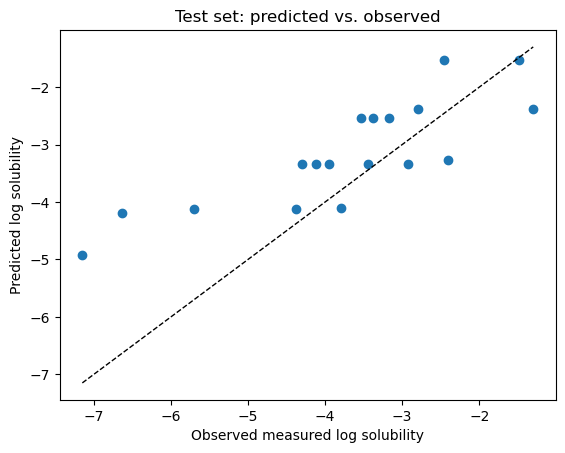

In [7]:
y_pred_test = fitted_model.predict(X_test)

plt.scatter(y_test, y_pred_test)
lims = [min(*y_test, *y_pred_test), max(*y_test, *y_pred_test)]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Observed measured log solubility")
plt.ylabel("Predicted log solubility")
plt.title("Test set: predicted vs. observed")
plt.show()

## 7. Algorithm comparison

`Model()` supports many regressor types through its `M` argument. Fit
several and compare held-out test R² and 5-fold cross-validated Q².

In [8]:
candidate_models = ["mlr", "pls", "rf", "gb", "svm"]
comparison_rows = []
for m_name in candidate_models:
    res, cv, fitted, _ = Model(
        X_train, y_train, X_test, y_test, v_names, M=m_name, c=3, rs=0, cv="kf"
    )
    comparison_rows.append(
        {"model": m_name, "R2_test": res["R2_test"], "Q2_CV": cv["q2"]}
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
comparison_df

,R2_test,Q2_CV
model,,
mlr,0.631516,0.457919
pls,0.660155,0.291983
rf,0.519130,0.317555
gb,0.655005,0.539336
svm,0.623273,0.641754


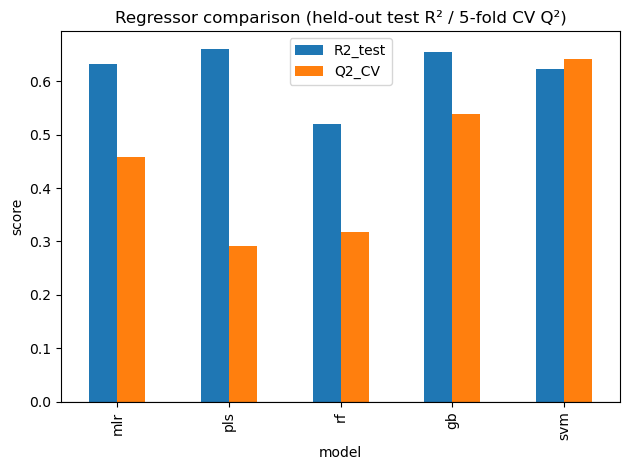

In [9]:
comparison_df.plot.bar()
plt.ylabel("score")
plt.title("Regressor comparison (held-out test R² / 5-fold CV Q²)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Hyperparameter + feature-selection search

Two things worth tuning together: `ndes` (how many features
`data_prep()`'s feature selection keeps) and, for a random forest, `c`
(which controls `n_estimators`, `max_depth`, and `max_features` together).
Changing `ndes` changes the feature set itself, so each value needs its
own `data_prep()` call; `c` is then swept for each resulting feature set.
The combination with the best cross-validated Q² is kept as the "best
model" for the rest of the notebook.

In [10]:
ndes_values = [4, 6, 8, 10]
c_values = [2, 3, 4, 5, 6]

datasets_by_ndes = {}
search_rows = []
for ndes in ndes_values:
    res = data_prep(
        "merged.csv", Scaled="on", Cor="on", FS="reg", ndes=ndes,
        TARGET="measured_logS", mod="reg", ratio=0.25, rs=0,
    )
    datasets_by_ndes[ndes] = res[:5]
    Xtr, ytr, Xte, yte, vnames = res[:5]
    for c in c_values:
        if c > ndes:
            continue
        r, cv, fitted, _ = Model(Xtr, ytr, Xte, yte, vnames, M="rf", c=c, rs=0, cv="kf")
        search_rows.append(
            {"ndes": ndes, "c": c, "R2_test": r["R2_test"], "Q2_CV": cv["q2"], "RMSE_CV": cv["RMSECV"]}
        )

search_df = pd.DataFrame(search_rows)
best_row = search_df.loc[search_df["Q2_CV"].idxmax()]
print("Best configuration by CV Q²:")
print(best_row)

Best configuration by CV Q²:
ndes       6.000000
c          6.000000
R2_test    0.425533
Q2_CV      0.503543
RMSE_CV    1.420335
Name: 7, dtype: float64


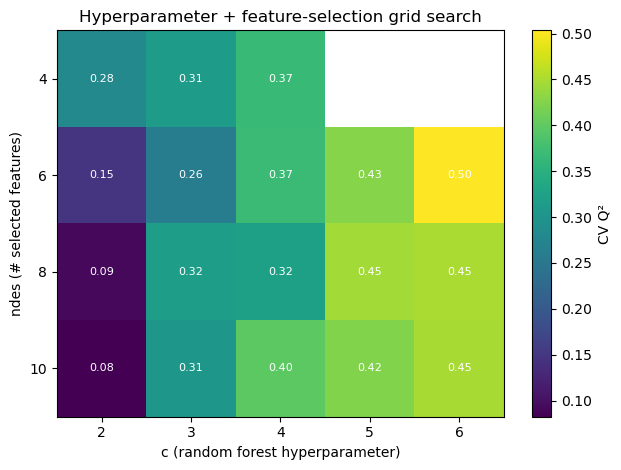

In [11]:
pivot = search_df.pivot(index="ndes", columns="c", values="Q2_CV")
plt.imshow(pivot, cmap="viridis", aspect="auto")
plt.colorbar(label="CV Q²")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("c (random forest hyperparameter)")
plt.ylabel("ndes (# selected features)")
plt.title("Hyperparameter + feature-selection grid search")
for i, ndes in enumerate(pivot.index):
    for j, c in enumerate(pivot.columns):
        val = pivot.loc[ndes, c]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color="white", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Best model: refit and diagnostics

Refit the winning `(ndes, c)` combination and look at it in more detail:
predicted-vs-observed and a residual plot on the test set. This -- not
section 5's arbitrary starting guess -- is the model the rest of the
notebook uses.

In [12]:
best_ndes = int(best_row["ndes"])
best_c = int(best_row["c"])
X_train, y_train, X_test, y_test, v_names = datasets_by_ndes[best_ndes]

model_result, cv_metrics, fitted_model, analysis = Model(
    X_train, y_train, X_test, y_test, v_names, M="rf", c=best_c, rs=0, cv="kf"
)
print(f"Best model: rf, ndes={best_ndes}, c={best_c}")
print(f"Test R^2:  {model_result['R2_test']:.3f}")
print(f"CV Q^2:    {cv_metrics['q2']:.3f}")
print(f"CV RMSE:   {cv_metrics['RMSECV']:.3f}")

Best model: rf, ndes=6, c=6
Test R^2:  0.426
CV Q^2:    0.504
CV RMSE:   1.420


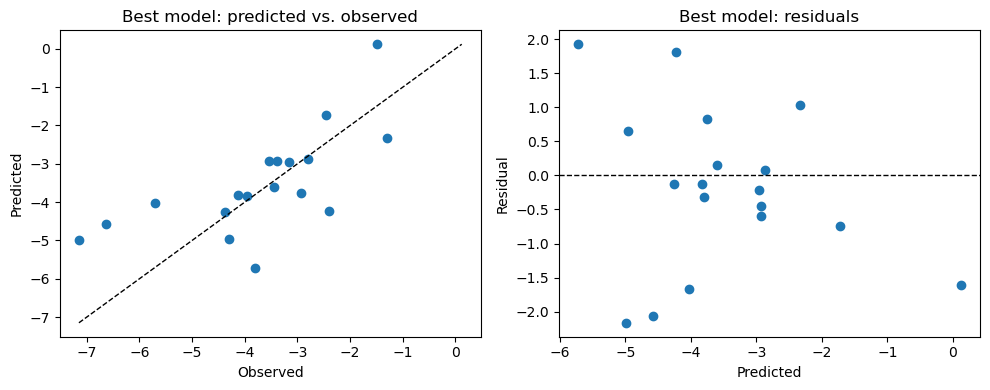

In [13]:
y_pred_test = fitted_model.predict(X_test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lims = [min(*y_test, *y_pred_test), max(*y_test, *y_pred_test)]
axes[0].scatter(y_test, y_pred_test)
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Best model: predicted vs. observed")

axes[1].scatter(y_pred_test, residuals)
axes[1].axhline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Best model: residuals")

plt.tight_layout()
plt.show()

## 10. Feature importance

`Model()`'s result already includes a sorted variable-importance table.
`partial()` goes a step further with partial dependence plots -- it
accepts that same table directly, since both use the same
`{feature: score}` shape.

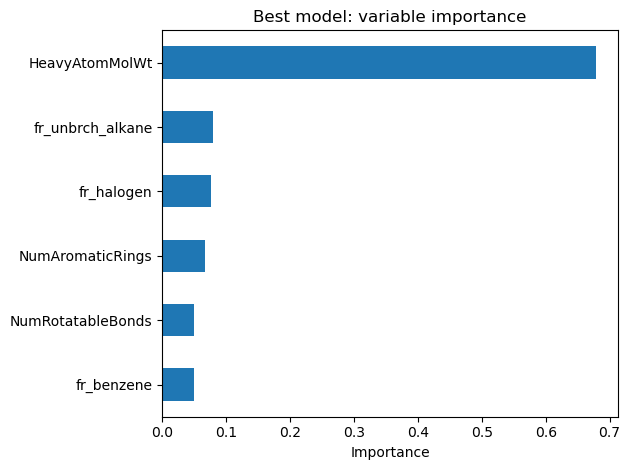

In [14]:
model_result["Variable Importance"].plot.barh(legend=False)
plt.xlabel("Importance")
plt.title("Best model: variable importance")
plt.tight_layout()
plt.show()

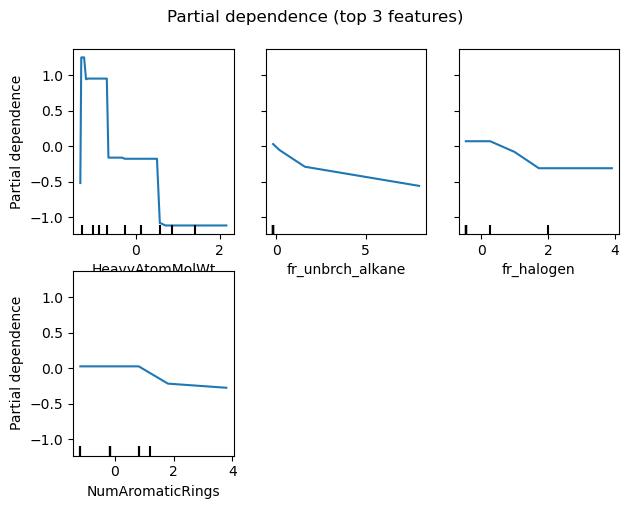

In [15]:
from mlmolprop import partial

partial(X_train, y_train, model_result["Variable Importance"], n_features=3, kind="reg", show=False)
plt.suptitle("Partial dependence (top 3 features)", y=1.05)
plt.show()

## 11. LIME: explaining a single prediction

Where variable importance and partial dependence describe the model
globally, LIME explains one prediction at a time -- which features pushed
*this molecule's* prediction up or down.

`lime_explain()` estimates its perturbation statistics from the entire `x`
argument passed in, not just the row being explained -- so pass the whole
test set and use `start=` to pick which row to actually explain, rather
than a single-row DataFrame (which would give LIME nothing to estimate
feature variance from).

Molecule: 62
Observed: -4.12   Predicted: -3.56
  fr_halogen <= -0.47                 +0.602
  0.36 < HeavyAtomMolWt <= 0.90       -0.520
  fr_unbrch_alkane <= -0.17           +0.313
  fr_benzene <= -0.99                 +0.101
  NumAromaticRings <= -0.93           +0.048
  NumRotatableBonds <= -0.68          +0.006


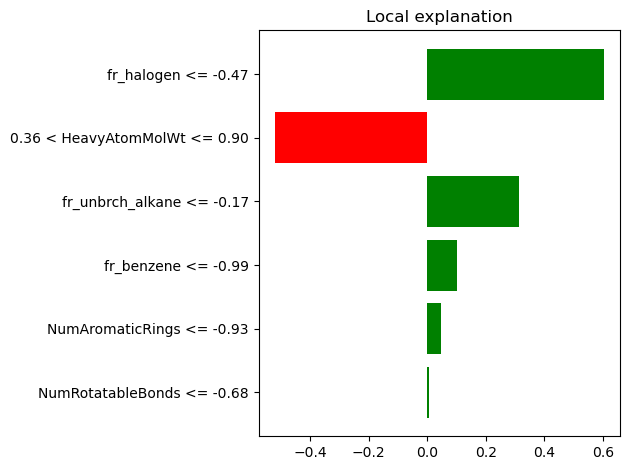

In [16]:
from sklearn.ensemble import RandomForestRegressor

from mlmolprop import lime_explain

rf_for_lime = RandomForestRegressor(n_estimators=50, random_state=0).fit(X_train, y_train)

explanations = lime_explain(
    rf_for_lime, X_test, v_names, y_test, mode="regression", start=len(X_test) - 1
)
mol_name, observed, predicted, contributions, exp = explanations[-1]

print(f"Molecule: {mol_name}")
print(f"Observed: {observed:.2f}   Predicted: {predicted:.2f}")
for feature_desc, weight in contributions:
    print(f"  {feature_desc:35s} {weight:+.3f}")
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## 12. 2D structure depictions

`moltosvg()` renders a molecule to SVG -- here from `prepared_2d.sdf`, the
2D-coordinate file `mol_enumerate` already wrote in step 2. `highlight()`
does the same but highlights atoms matching a SMARTS substructure pattern,
useful for pointing out *why* a molecule matched a filter.

5_fluorouracil


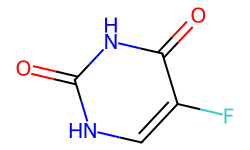

ddt


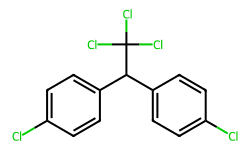

estradiol


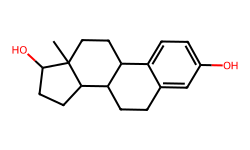

uracil


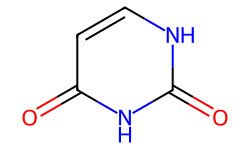

In [17]:
from IPython.display import SVG, display
from rdkit import Chem

from mlmolprop import highlight, moltosvg

with Chem.SDMolSupplier("prepared_2d.sdf") as suppl:
    mols_2d = {m.GetProp("_Name"): m for m in suppl if m is not None}

for name in ["5_fluorouracil", "ddt", "estradiol", "uracil"]:
    print(name)
    display(SVG(moltosvg(mols_2d[name], molSize=(250, 150))))

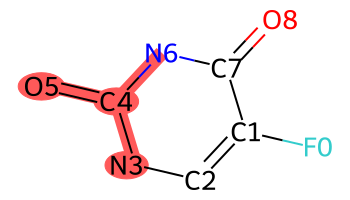

In [18]:
# Highlight the pyrimidinedione carbonyl/amide-like substructure in
# 5-fluorouracil. Note the lowercase c/n: RDKit perceives this ring as
# aromatic, and SMARTS is case-sensitive -- uppercase C/N only match
# *aliphatic* atoms, so "C(=O)N" (uppercase) matches nothing here and
# highlight() would silently highlight zero atoms.
fluorouracil_smiles = esol.loc[esol["name"] == "5_fluorouracil", "smiles"].iloc[0]
display(SVG(highlight(fluorouracil_smiles, "c(=O)n", size=(350, 200))))

## 13. Low-dimensional map and clustering

`clus_uns()` runs PCA (or K-means on the PCA scores) and returns the
component scores it computed. Here they're reused for a scatter colored by
the *continuous* measured activity -- `clus_uns()`'s own built-in plots
color by a small number of discrete classes, which suits its other main
use (K-means cluster assignment) better than a continuous QSAR target.

[1 0 0 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1
 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1]


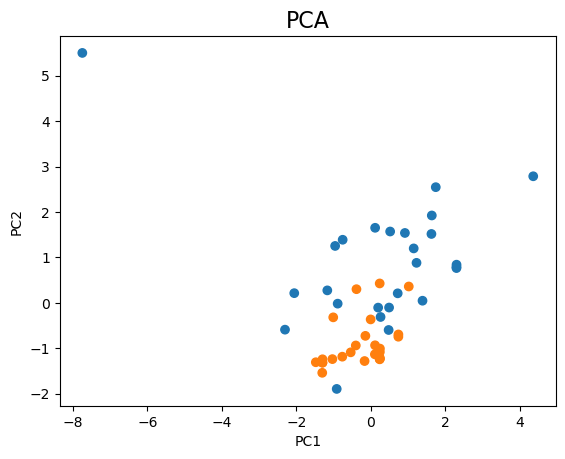

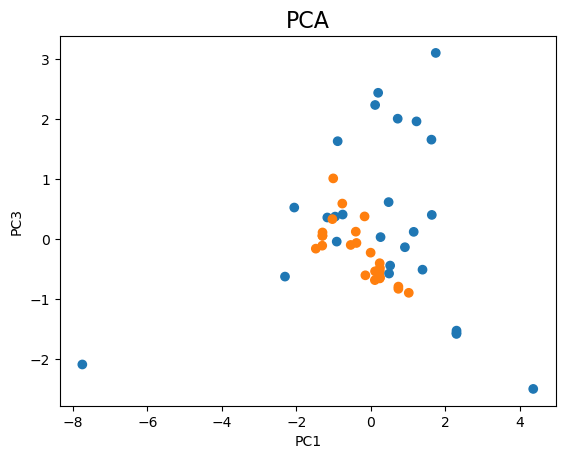

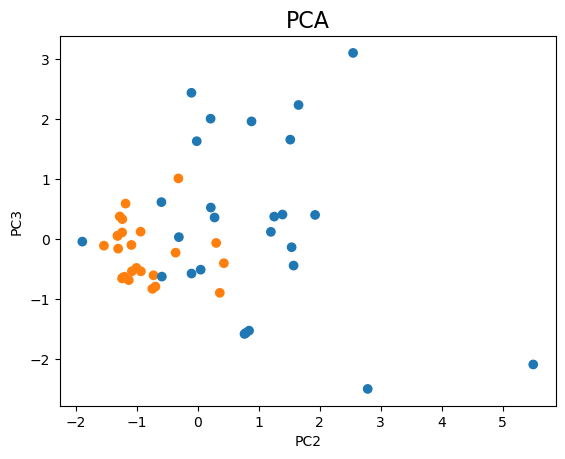

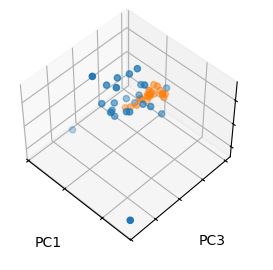

In [19]:
from mlmolprop import clus_uns

y_train_binary_for_pca = (y_train > np.median(y_train)).astype(int)
pc1, pc2, pc3 = clus_uns(X_train, y_train_binary_for_pca, path="./", M="pca", n=2)

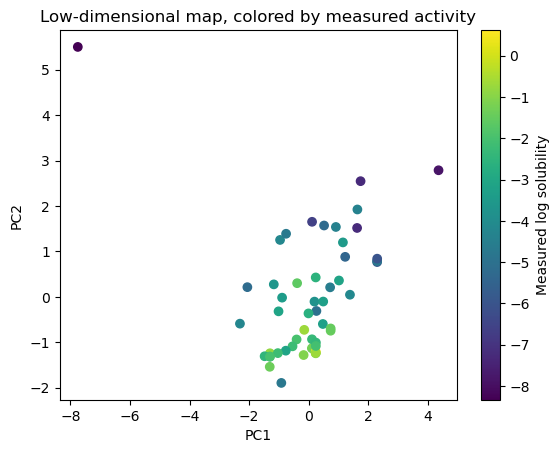

In [20]:
plt.figure()
sc = plt.scatter(pc1, pc2, c=y_train, cmap="viridis")
plt.colorbar(sc, label="Measured log solubility")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Low-dimensional map, colored by measured activity")
plt.show()

K-means clustering on the PCA scores (a "clustering map"):

[1 0 0 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1
 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1]


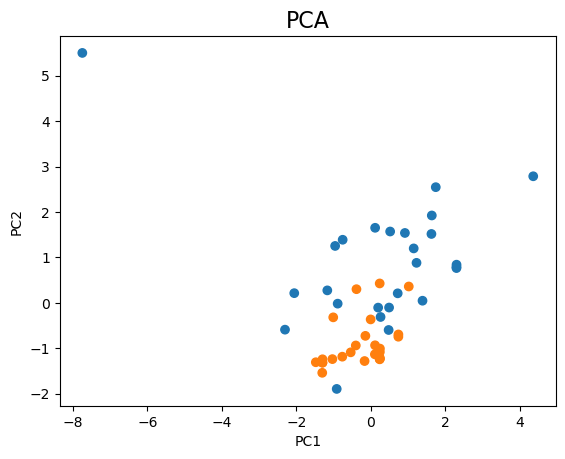

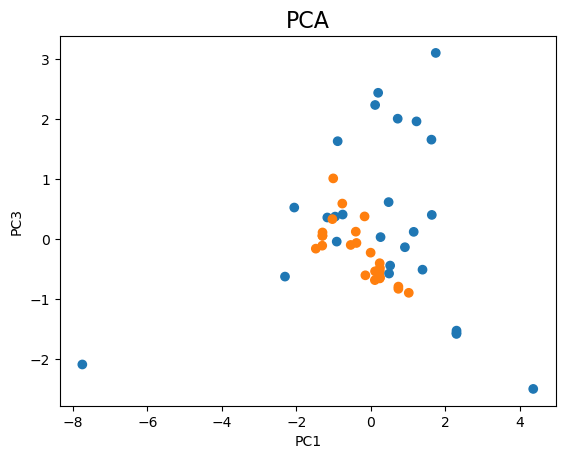

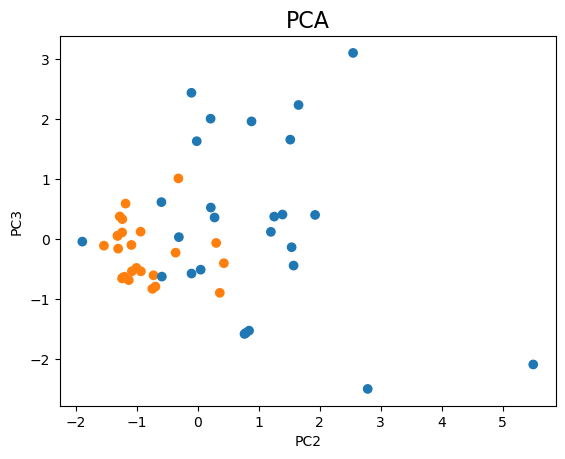

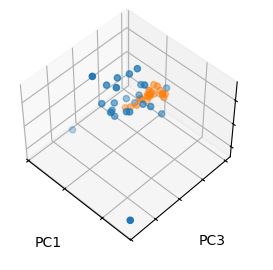

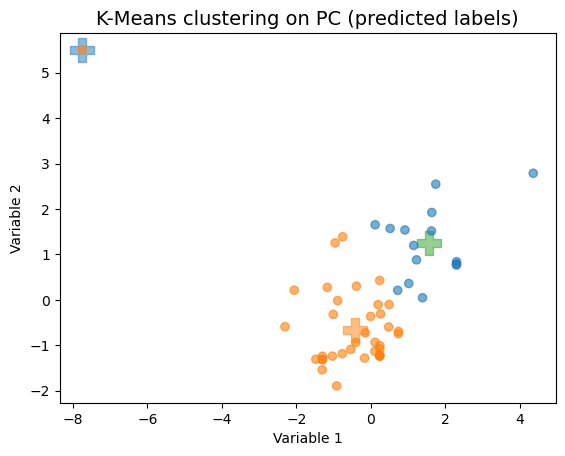

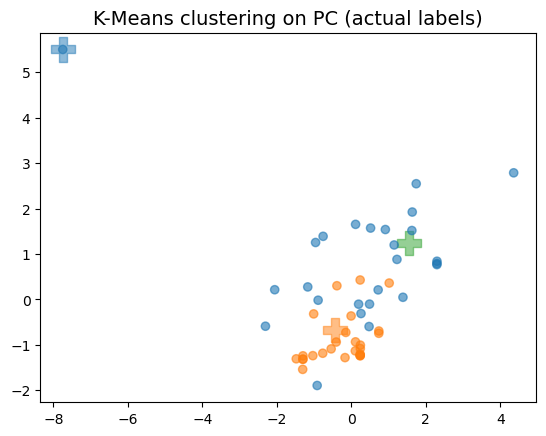

In [21]:
clus_uns(X_train, y_train_binary_for_pca, path="./", M="pc-km", n=2, n2=3)

## 14. Classification, confusion matrices, and a Keras deep-learning model

Threshold the measured solubility into soluble/insoluble at the median,
then compare a few classifiers. `ModelC()` automatically plots
train/cross-validation/test confusion matrices as a side effect of each
call; the comparison loop below closes each model's figures immediately
(`plt.close("all")`) to avoid a wall of repeated plots, then the actual
best-by-CV model is refit once more so its confusion matrices render.

In [22]:
from mlmolprop import ModelC

y_train_binary = (y_train > np.median(y_train)).astype(int)
y_test_binary = (y_test > np.median(y_test)).astype(int)

classifier_candidates = ["rf", "lr", "svm"]
class_rows = []
for m_name in classifier_candidates:
    res, fitted = ModelC(
        X_train, y_train_binary, X_test, y_test_binary, v_names, M=m_name, c1=3, rs=0, cv="kf"
    )
    class_rows.append(
        {
            "model": m_name,
            "train_accuracy": res["accuracy_score_train"],
            "test_accuracy": res["accuracy_score_test"],
            "cv_accuracy": res["accuracy_score_LOO"],
        }
    )
    plt.close("all")  # suppress this loop's confusion-matrix plots; the winner gets refit below

class_df = pd.DataFrame(class_rows).set_index("model")
class_df

,train_accuracy,test_accuracy,cv_accuracy
model,,,
rf,0.923077,0.722222,0.846154
lr,0.865385,0.611111,0.788462
svm,1.000000,0.611111,0.788462


Best classifier by CV accuracy: rf


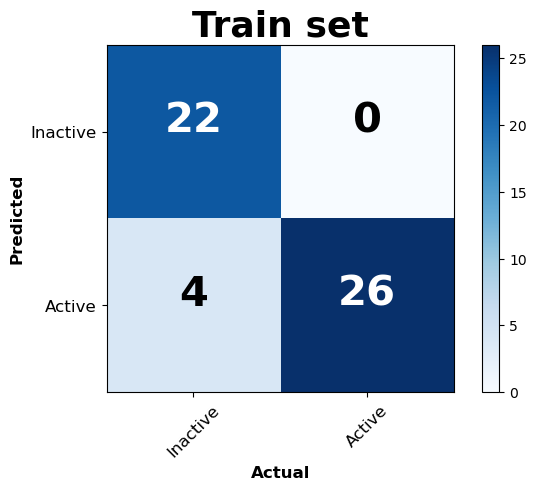

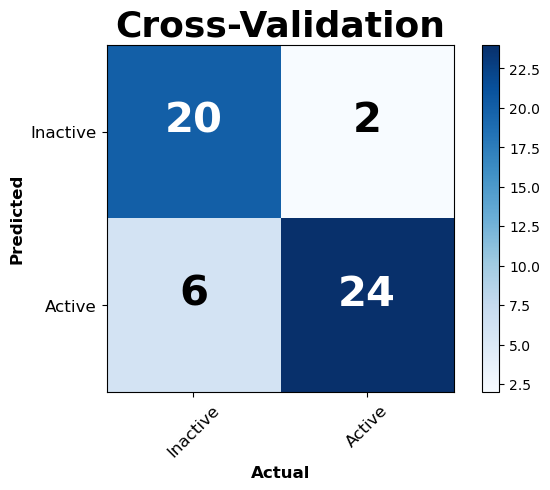

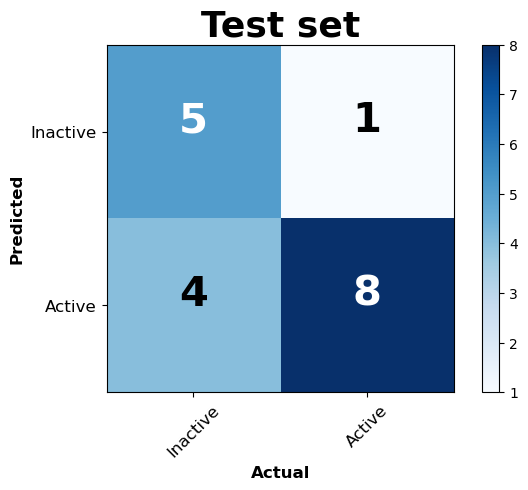

In [23]:
best_classifier = class_df["cv_accuracy"].idxmax()
print(f"Best classifier by CV accuracy: {best_classifier}")

best_class_result, best_class_model = ModelC(
    X_train, y_train_binary, X_test, y_test_binary, v_names, M=best_classifier, c1=3, rs=0, cv="kf"
)

Now a small Keras MLP (`M="dl"`), letting its own confusion matrices
render too -- train set, stratified cross-validation, and the held-out
test set.

2026-08-07 01:52:30.199396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train accuracy: 0.865
Test accuracy:  0.722


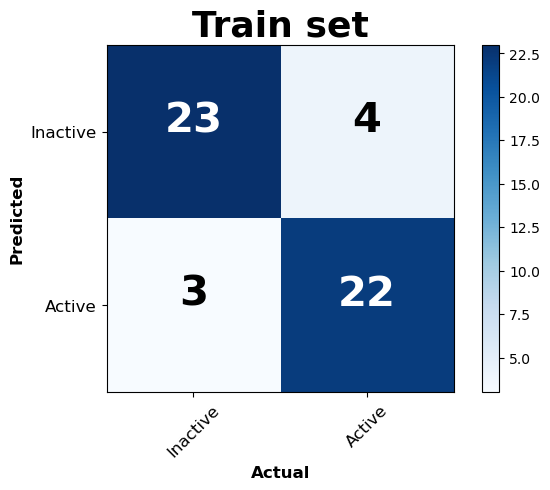

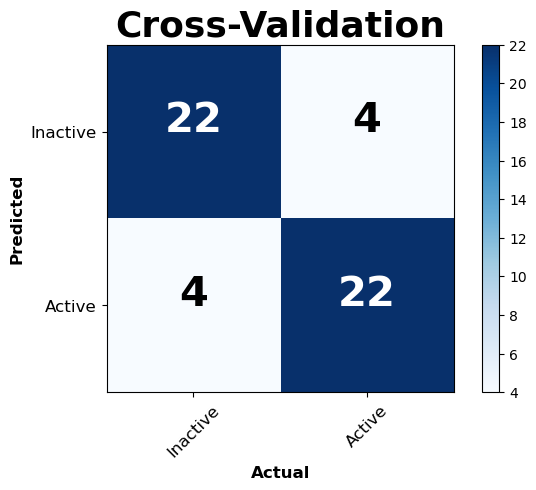

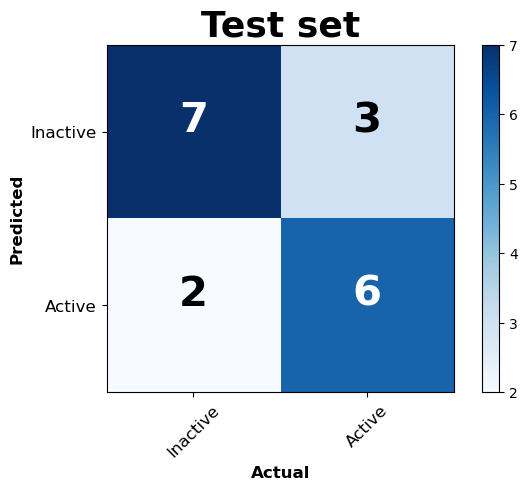

In [24]:
dl_result, dl_model = ModelC(
    X_train, y_train_binary, X_test, y_test_binary, v_names,
    M="dl", rs=0, ep=30, dl2=[8, 4], bs=8,
)
print(f"Train accuracy: {dl_result['accuracy_score_train']:.3f}")
print(f"Test accuracy:  {dl_result['accuracy_score_test']:.3f}")

## Next steps

- Swap in your own SDF/SMILES file and activity data -- everything above
  works the same way.
- See the module table in the repo's `README.md` for everything not shown
  here (correlation filtering, applicability-domain checks, more
  fingerprint types, ...).